# Projeto: Redução de Dimensionalidade em Imagens (sem bibliotecas)

Autor: Alex Alves Inácio  
Data: 2025

## Objetivo
- Ler uma imagem colorida (JPEG)
- Converter para formato PPM P3 (texto)
- Implementar manualmente:
  - RGB → escala de cinza (0–255)
  - cinza → binária (0 ou 255)
- Salvar:
  - PGM (P2 – texto)
  - PBM (P1 – texto)


In [3]:
!apt-get -y install imagemagick
from google.colab import files
uploaded = files.upload()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 ghostscript gsfonts
  imagemagick-6-common imagemagick-6.q16 libdjvulibre-text libdjvulibre21
  libfftw3-double3 libgs9 libgs9-common libidn12 libijs-0.35 libilmbase25
  libjbig2dec0 libjxr-tools libjxr0 liblqr-1-0 libmagickcore-6.q16-6
  libmagickcore-6.q16-6-extra libmagickwand-6.q16-6 libnetpbm10 libopenexr25
  libwmflite-0.2-7 netpbm poppler-data
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre
  ghostscript-x imagemagick-doc autotrace cups-bsd | lpr | lprng enscript gimp
  gnuplot grads hp2xx html2ps libwmf-bin mplayer povray radiance sane-utils
  texlive-base-bin transfig ufraw-batch libfftw3-bin libfftw3-dev inkscape
  poppler-utils fonts-japanese-mincho | fonts-ipafont-mincho
  fonts-japanese-gothic | fonts-ipafont-gothic fonts-arphic-uka

Saving c.jpeg to c (1).jpeg


In [4]:
# Converte a imagem JPEG para PPM P3 (formato texto)
!convert c.jpeg -compress none -define ppm:format=plain entrada.ppm

print("Conversão concluída! Arquivo gerado: entrada.ppm")

Conversão concluída! Arquivo gerado: entrada.ppm


In [5]:
def ler_ppm(nome_arquivo):
    """
    Lê uma imagem no formato PPM P3 (texto) e retorna:

    - largura (int)
    - altura (int)
    - lista de pixels no formato [(R, G, B), ...]

    Suposições:
    - Arquivo não possui linhas de comentário entre o cabeçalho.
    - Valor máximo de cor é 255.
    """
    ...

    with open(nome_arquivo, "r") as f:
        # 1) Primeira linha: tipo do arquivo (deve ser 'P3')
        tipo = f.readline().strip()
        if tipo != "P3":
            raise ValueError(f"Tipo de arquivo não suportado: {tipo}. Esperado: P3")

        # 2) Segunda linha: largura e altura
        #    (estamos assumindo que não há comentários no arquivo)
        largura, altura = map(int, f.readline().split())

        # 3) Terceira linha: valor máximo (normalmente 255)
        maxval = int(f.readline().strip())
        if maxval != 255:
            print("Aviso: valor máximo diferente de 255:", maxval)

        # 4) Restante do arquivo: valores R G B separados por espaços
        #    Ex.: R G B R G B R G B ...
        valores = f.read().split()
        valores = list(map(int, valores))  # converte cada string para int

        pixels = []
        # A cada 3 valores temos um pixel (R, G, B)
        for i in range(0, len(valores), 3):
            R = valores[i]
            G = valores[i + 1]
            B = valores[i + 2]
            pixels.append((R, G, B))

    return largura, altura, pixels


In [6]:
largura, altura, pixels_coloridos = ler_ppm("entrada.ppm")

print("Largura:", largura)
print("Altura:", altura)
print("Total de pixels lidos:", len(pixels_coloridos))
print("Primeiro pixel (R,G,B):", pixels_coloridos[0])


Largura: 284
Altura: 178
Total de pixels lidos: 50552
Primeiro pixel (R,G,B): (0, 177, 210)


In [7]:
def converter_para_cinza(lista_pixels_rgb):
    """
    Recebe uma lista de pixels [(R,G,B), ...]
    Retorna uma lista de níveis de cinza [g1, g2, ...]
    onde cada g está entre 0 e 255.

    Fórmula usada (luminância aproximada do olho humano):
        cinza = 0.299*R + 0.587*G + 0.114*B
    """
    pixels_cinza = []

    for (R, G, B) in lista_pixels_rgb:
        g = int(0.299 * R + 0.587 * G + 0.114 * B)
        pixels_cinza.append(g)

    return pixels_cinza


In [8]:
pixels_cinza = converter_para_cinza(pixels_coloridos)

print("Quantidade de pixels em cinza:", len(pixels_cinza))
print("Primeiro pixel em cinza:", pixels_cinza[0])

# conferência extra: deve ser igual a largura * altura
print("Largura * Altura:", largura * altura)


Quantidade de pixels em cinza: 50552
Primeiro pixel em cinza: 127
Largura * Altura: 50552


In [9]:
def converter_para_binario(lista_pixels_cinza, limite=128):
    """
    Converte lista de cinza para binário 0 ou 255.
    limite = valor de corte (threshold)
    """
    pixels_binarios = []

    for g in lista_pixels_cinza:
        if g < limite:
            pixels_binarios.append(0)
        else:
            pixels_binarios.append(255)

    return pixels_binarios


In [10]:
pixels_bin = converter_para_binario(pixels_cinza)

print("Quantidade de pixels binários:", len(pixels_bin))
print("Primeiro pixel binário:", pixels_bin[0])
print("Valores únicos encontrados:", set(pixels_bin))


Quantidade de pixels binários: 50552
Primeiro pixel binário: 0
Valores únicos encontrados: {0, 255}


In [26]:
def salvar_pgm(nome_arquivo, largura, altura, pixels_cinza):
    """
    Salva uma imagem em formato PGM P2 (texto)
    """
    with open(nome_arquivo, "w") as f:
        f.write("P2\n")
        f.write(f"{largura} {altura}\n")
        f.write("255\n")  # valor máximo de cinza

        # escreve os pixels, 15 por linha para legibilidade
        for i, g in enumerate(pixels_cinza):
            f.write(f"{g} ")
            if (i + 1) % 15 == 0:
                f.write("\n")

    print(f"Arquivo PGM salvo como: {nome_arquivo}")

salvar_pgm("saida_cinza.pgm", largura, altura, pixels_cinza)


Arquivo PGM salvo como: saida_cinza.pgm


In [16]:
# Gera a imagem binária em PBM
salvar_pbm("saida_binaria.pbm", largura, altura, pixels_bin)


Arquivo PBM salvo como: saida_binaria.pbm


In [29]:
def salvar_pbm(nome_arquivo, largura, altura, pixels_bin):
    """
    Salva uma imagem em formato PBM P1 (texto)
    """
    with open(nome_arquivo, "w") as f:
        f.write("P1\n")
        f.write(f"{largura} {altura}\n")

        # PBM usa 0 e 1 (não 0 e 255)
        for i, g in enumerate(pixels_bin):
            bit = 0 if g == 0 else 1
            f.write(f"{bit} ")
            if (i + 1) % 30 == 0:
                f.write("\n")

    print(f"Arquivo PBM salvo como: {nome_arquivo}")

salvar_pbm("saida_cinza.pgm", largura, altura, pixels_cinza)



Arquivo PBM salvo como: saida_cinza.pgm


In [30]:
# Gera a imagem em tons de cinza (PGM) – você já tem essa chamada em uma célula anterior,
# mas deixo aqui o par completo pra ficar claro:
salvar_pgm("saida_cinza.pgm", largura, altura, pixels_cinza)

# Gera a imagem binária (PBM)
salvar_pbm("saida_binaria.pbm", largura, altura, pixels_bin)


Arquivo PGM salvo como: saida_cinza.pgm
Arquivo PBM salvo como: saida_binaria.pbm


In [31]:
from PIL import Image

# Converter PGM para PNG
img_pgm = Image.open("saida_cinza.pgm")
img_pgm.save("saida_cinza.png")

# Converter PBM para PNG
img_pbm = Image.open("saida_binaria.pbm")
img_pbm.save("saida_binaria.png")

print("Conversão concluída!")


Conversão concluída!


Imagem em tons de cinza:


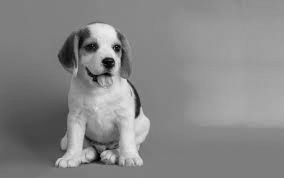

Imagem binária:


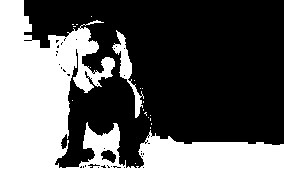

In [32]:
from IPython.display import Image, display

print("Imagem em tons de cinza:")
display(Image("saida_cinza.png"))

print("Imagem binária:")
display(Image("saida_binaria.png"))
